### ***Implementation Vanilla GAN***

In [1]:
import torch 
import os  
from torch.utils.data import DataLoader,Dataset 
from torchvision import transforms 
from PIL import Image 

In [2]:
# images load => transform => dataset of all imgs
class ImageProcessor:
    def __init__(self, root_dir_path, transformations=None):
        self.root_dir_path = root_dir_path
        self.transformations = transformations

        # list of paths for all images
        self.all_img_paths = [os.path.join(root_dir_path, img) for img in os.listdir(root_dir_path)]

    def __len__(self):
        return len(self.all_img_paths)

    def __getitem__(self, idx):
        img_path = self.all_img_paths[idx]
        img = Image.open(img_path).convert("RGB")

        if self.transformations:
            img = self.transformations(img)

        return img

root_dir_path = "./img/img_align_celeba"

In [3]:
transformations = transforms.Compose([
    transforms.CenterCrop(178),  # 178x218 => 178x178 
    transforms.Resize(64),  # 64x64 
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # [-1,1]
])

# Loading Dataset  
dataset = ImageProcessor(root_dir_path,transformations)
print(f"Loaded {len(dataset)} images")

Loaded 202599 images


In [4]:
dataloader = DataLoader(dataset, batch_size=128, shuffle=True)

#### Generator Network

In [5]:
import torch.nn as nn 
import torch.optim as optim 
import numpy as np 

In [6]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, img_channels=3): # 3 is for RGB
        super(Generator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Linear(z_dim, 256), # 100 => 256
            nn.ReLU(),

            nn.Linear(256, 512), 
            nn.ReLU(),

            nn.Linear(512, 1024), 
            nn.ReLU(),

            nn.Linear(1024, 64 * 64 * img_channels), 
            nn.Tanh() # [-1, 1]
        )

    def forward(self, z):
        img = self.model(z)
        img = img.view(img.size(0), 3, 64, 64) 
        return img

        # fake img => 64 x 64 x 3 x batch_size

#### Discriminator Network

In [7]:
class Discriminator(nn.Module):
    def __init__(self, img_channels=3): # 3 is for RGB
        super(Discriminator, self).__init__()

        # fully connected (dense) layers
        self.model = nn.Sequential(
            nn.Flatten(), # 4D tensor => 1D
            
            nn.Linear(img_channels * 64 * 64, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256), 
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1), 
            nn.Sigmoid() # probability of being real/fake 
        )

    def forward(self, img):
        return self.model(img)

In [8]:
GAN_loss = nn.BCELoss()

generator = Generator()
g_optimizer = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

discriminator = Discriminator()
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [9]:
import torch 

# Check Device Availability 
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"device is {device}")

device is cpu


In [10]:
generator = generator.to(device)
discriminator = discriminator.to(device)

#### Training Our GAN Model

In [11]:
def train(generator, discriminator, dataloader, epochs=10):

    for epoch in range(epochs):
        for i, imgs in enumerate(dataloader):
            real_imgs = imgs.to(device)
            batch_size = real_imgs.size(0)

            # creates real imgs labels & fake imgs labels
            real_labels = torch.ones(batch_size, 1).to(device) # [1, 1, 1....]
            fake_labels = torch.zeros(batch_size, 1).to(device) # [0, 0, 0....]

            # Train the Discriminator
            d_optimizer.zero_grad()

            fake_imgs = generator(torch.randn(batch_size, 100).to(device))

            real_loss = GAN_loss(discriminator(real_imgs), real_labels)
            fake_loss = GAN_loss(discriminator(fake_imgs.detach()), fake_labels)

            d_loss = (real_loss + fake_loss) / 2

            d_loss.backward()
            d_optimizer.step()

            # Train the Generator
            g_optimizer.zero_grad()

            g_loss = GAN_loss(discriminator(fake_imgs), real_labels)

            g_loss.backward()
            g_optimizer.step()

            if i % 50 == 0:
                print(f"for epoch: {epoch+1}/{epochs}... batch: {i+1}... G-loss:{g_loss}.... D-loss: {d_loss}")

        # save generated imgs for each epoch
        save_generated_images(generator, epoch, device) 

In [12]:
import matplotlib.pyplot as plt
import torchvision

def save_generated_images(generator, epoch, device, num_imgs=8):
    z = torch.randn(num_imgs, 100).to(device)
    generated_imgs = generator(z).detach().cpu()

    grid = torchvision.utils.make_grid(generated_imgs, nrow=4, normalize=True)

    plt.imshow(np.transpose(grid, (1, 2, 0)))
    plt.title(f"epoch {epoch+1}")
    plt.axis("off")
    plt.show()

for epoch: 1/17... batch: 1... G-loss:0.6984801888465881.... D-loss: 0.6947451829910278
for epoch: 1/17... batch: 51... G-loss:1.0908842086791992.... D-loss: 0.255199134349823
for epoch: 1/17... batch: 101... G-loss:2.026010274887085.... D-loss: 0.1255572885274887
for epoch: 1/17... batch: 151... G-loss:0.8760785460472107.... D-loss: 0.3551484942436218
for epoch: 1/17... batch: 201... G-loss:1.0029133558273315.... D-loss: 0.36020427942276
for epoch: 1/17... batch: 251... G-loss:1.0955978631973267.... D-loss: 0.256900429725647
for epoch: 1/17... batch: 301... G-loss:0.7401928901672363.... D-loss: 0.8630459904670715
for epoch: 1/17... batch: 351... G-loss:1.7568366527557373.... D-loss: 0.15854761004447937
for epoch: 1/17... batch: 401... G-loss:2.6416492462158203.... D-loss: 0.08064723759889603
for epoch: 1/17... batch: 451... G-loss:2.2074337005615234.... D-loss: 0.1375662237405777
for epoch: 1/17... batch: 501... G-loss:1.8704476356506348.... D-loss: 0.4814666509628296
for epoch: 1/17.

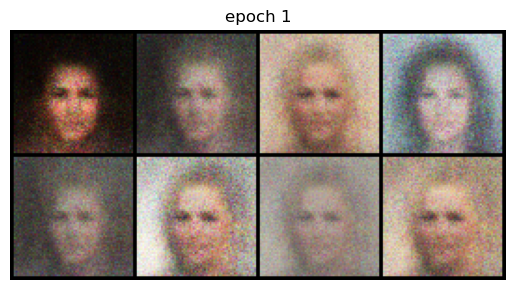

for epoch: 2/17... batch: 1... G-loss:3.27339506149292.... D-loss: 0.3245041072368622
for epoch: 2/17... batch: 51... G-loss:3.0446605682373047.... D-loss: 0.25172555446624756
for epoch: 2/17... batch: 101... G-loss:1.6849371194839478.... D-loss: 0.36473312973976135
for epoch: 2/17... batch: 151... G-loss:3.163357734680176.... D-loss: 0.32891103625297546
for epoch: 2/17... batch: 201... G-loss:2.5679771900177.... D-loss: 0.35737258195877075
for epoch: 2/17... batch: 251... G-loss:2.171463966369629.... D-loss: 0.35215431451797485
for epoch: 2/17... batch: 301... G-loss:2.5358188152313232.... D-loss: 0.25242650508880615
for epoch: 2/17... batch: 351... G-loss:3.006112575531006.... D-loss: 0.22228720784187317
for epoch: 2/17... batch: 401... G-loss:3.9785730838775635.... D-loss: 0.2622756063938141
for epoch: 2/17... batch: 451... G-loss:2.169346332550049.... D-loss: 0.4094972610473633
for epoch: 2/17... batch: 501... G-loss:2.578580141067505.... D-loss: 0.30041950941085815
for epoch: 2/17

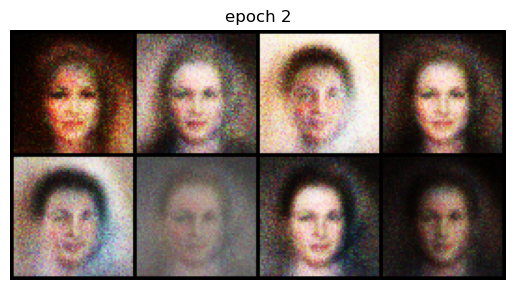

for epoch: 3/17... batch: 1... G-loss:2.774766445159912.... D-loss: 0.41039586067199707
for epoch: 3/17... batch: 51... G-loss:1.8353554010391235.... D-loss: 0.41027697920799255
for epoch: 3/17... batch: 101... G-loss:1.783640742301941.... D-loss: 0.4920715093612671
for epoch: 3/17... batch: 151... G-loss:1.7674410343170166.... D-loss: 0.32913994789123535
for epoch: 3/17... batch: 201... G-loss:1.8143525123596191.... D-loss: 0.3738674521446228
for epoch: 3/17... batch: 251... G-loss:2.121234178543091.... D-loss: 0.5889075398445129
for epoch: 3/17... batch: 301... G-loss:2.0036985874176025.... D-loss: 0.4795783758163452
for epoch: 3/17... batch: 351... G-loss:2.171588897705078.... D-loss: 0.3153557777404785
for epoch: 3/17... batch: 401... G-loss:2.4440715312957764.... D-loss: 0.4591514468193054
for epoch: 3/17... batch: 451... G-loss:1.9192713499069214.... D-loss: 0.42973899841308594
for epoch: 3/17... batch: 501... G-loss:1.8721445798873901.... D-loss: 0.4624067544937134
for epoch: 3/

In [ ]:
train(generator, discriminator, dataloader, epochs=3)